<a href="https://colab.research.google.com/github/MishterBluesky/CoEVFold/blob/main/Bootstrapped_CoEV_Mapper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CoEV_Mapper 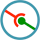

This notebook, derived from MMSEQ2 and GREMLIN finds co-evolutionary interactions based on the input sequence, creating a network of interactions. In order to work, it randomly removes amino acids from sequences, meaning what we see here is at the gene level, for specifics, the proteins must be put in other engines.

It will create a network and heatmap of which genes likely interact with each based on a normaised score to self.

Note: It is now promiscuity adjusted, leak adjusted and bootstrapped! it does the best it can with coevolution to make maps. There is nothing better.

In [16]:
%%time
#@title setup
unified_memory = True #@param {type:"boolean"}
import os, time, gc
if unified_memory:
  ENV = {"TF_FORCE_UNIFIED_MEMORY":"1", "XLA_PYTHON_CLIENT_MEM_FRACTION":"4.0"}
  for k,v in ENV.items(): os.environ[k] = v
if not os.path.isdir("params"):
  # get code
  print("installing ColabDesign")
  os.system("(mkdir params; apt-get install aria2 -qq; \
  aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar; \
  tar -xf alphafold_params_2022-12-06.tar -C params; touch params/done.txt )&")

  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git@gamma")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")
  os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/main/colabfold/colabfold.py -O colabfold_utils.py")
  #os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/beta/colabfold/mmseqs/api.py")

  # install hhsuite
  print("installing HHsuite")
  os.makedirs("hhsuite", exist_ok=True)
  os.system(f"curl -fsSL https://github.com/soedinglab/hh-suite/releases/download/v3.3.0/hhsuite-3.3.0-SSE2-Linux.tar.gz | tar xz -C hhsuite/")

  # download params
  if not os.path.isfile("params/done.txt"):
    print("downloading AlphaFold params")
    while not os.path.isfile("params/done.txt"):
      time.sleep(5)
if "hhsuite" not in os.environ['PATH']:
  os.environ['PATH'] += ":hhsuite/bin:hhsuite/scripts"

import re, tempfile
from IPython.display import HTML
from google.colab import files
import numpy as np
from colabdesign import mk_af_model, clear_mem
from colabdesign.af.contrib import predict
from colabdesign.af.contrib.cyclic import add_cyclic_offset
from colabdesign.shared.protein import _np_rmsd, _np_kabsch
from colabdesign.shared.plot import plot_pseudo_3D, pymol_cmap


import jax
import jax.numpy as jnp
from colabfold_utils import run_mmseqs2
import matplotlib.pyplot as plt
import string
import numpy as np

def clear_mem():
  backend = jax.lib.xla_bridge.get_backend()
  for buf in backend.live_buffers(): buf.delete()

def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://files.rcsb.org/download/{pdb_code}.cif -P tmp/")
    return f"tmp/{pdb_code}.cif"
  else:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v4.pdb -P tmp/")
    return f"tmp/AF-{pdb_code}-F1-model_v4.pdb"

def run_hhalign(query_sequence, target_sequence, query_a3m=None, target_a3m=None):
  with tempfile.NamedTemporaryFile() as tmp_query, \
  tempfile.NamedTemporaryFile() as tmp_target, \
  tempfile.NamedTemporaryFile() as tmp_alignment:
    if query_a3m is None:
      tmp_query.write(f">Q\n{query_sequence}\n".encode())
      tmp_query.flush()
      query_a3m = tmp_query.name
    if target_a3m is None:
      tmp_target.write(f">T\n{target_sequence}\n".encode())
      tmp_target.flush()
      target_a3m = tmp_target.name
    os.system(f"hhalign -hide_cons -i {query_a3m} -t {target_a3m} -o {tmp_alignment.name}")
    X, start_indices = predict.parse_hhalign_output(tmp_alignment.name)
  return X, start_indices

def run_do_not_align(query_sequence, target_sequence, **arg):
  return [query_sequence,target_sequence],[0,0]

def run_hhfilter(input, output, id=90, qid=10):
  os.system(f"hhfilter -id {id} -qid {qid} -i {input} -o {output}")

@jax.jit
def get_coevolution(X):
  '''given one-hot encoded MSA, return contacts'''
  Y = jax.nn.one_hot(X,22)
  N,L,A = Y.shape
  Y_flat = Y.reshape(N,-1)
  # covariance
  c = jnp.cov(Y_flat.T)

  # inverse covariance
  shrink = 4.5/jnp.sqrt(N) * jnp.eye(c.shape[0])
  ic = jnp.linalg.inv(c + shrink)

  # partial correlation coefficient
  ic_diag = jnp.diag(ic)
  pcc = ic / jnp.sqrt(ic_diag[:,None] * ic_diag[None,:])

  raw = jnp.sqrt(jnp.square(pcc.reshape(L,A,L,A)[:,:20,:,:20]).sum((1,3)))
  i = jnp.arange(L)
  raw = raw.at[i,i].set(0)
  # do apc
  ap = raw.sum(0,keepdims=True) * raw.sum(1,keepdims=True) / raw.sum()
  return (raw - ap).at[i,i].set(0)

def plot_3D(aux, Ls, file_name, show=False):
  plt.figure(figsize=(10,5))
  xyz = aux["atom_positions"][:,1]
  xyz = xyz @ _np_kabsch(xyz, xyz, return_v=True, use_jax=False)
  ax = plt.subplot(1,2,1)
  if len(Ls) > 1:
    plt.title("chain")
    c = np.concatenate([[n]*L for n,L in enumerate(Ls)])
    plot_pseudo_3D(xyz=xyz, c=c, cmap=pymol_cmap, cmin=0, cmax=39, Ls=Ls, ax=ax)
  else:
    plt.title("length")
    plot_pseudo_3D(xyz=xyz, Ls=Ls, ax=ax)
  plt.axis(False)
  ax = plt.subplot(1,2,2)
  plt.title("plddt")
  plot_pseudo_3D(xyz=xyz, c=aux["plddt"], cmin=0.5, cmax=0.9, Ls=Ls, ax=ax)
  plt.axis(False)
  plt.savefig(file_name, dpi=200, bbox_inches='tight')
  plt.show() if show else plt.close()

CPU times: user 373 µs, sys: 0 ns, total: 373 µs
Wall time: 358 µs


<>:31: SyntaxWarning:

invalid escape sequence '\('

<>:32: SyntaxWarning:

invalid escape sequence '\)'

<>:31: SyntaxWarning:

invalid escape sequence '\('

<>:32: SyntaxWarning:

invalid escape sequence '\)'

/tmp/ipython-input-2800480995.py:31: SyntaxWarning:

invalid escape sequence '\('

/tmp/ipython-input-2800480995.py:32: SyntaxWarning:

invalid escape sequence '\)'



jobname DivIVBPbpBSpoVEMreBFtsZFtsAMreCMurEMurDMurF_506d7_0
length=[263, 716, 366, 337, 382, 440, 290, 494, 451, 457] copies=1
getting paired MSA


COMPLETE: 100%|██████████| 1500/1500 [elapsed: 00:07 remaining: 00:00]


parsing msas
gathering info
filtering sequences
selecting final sequences


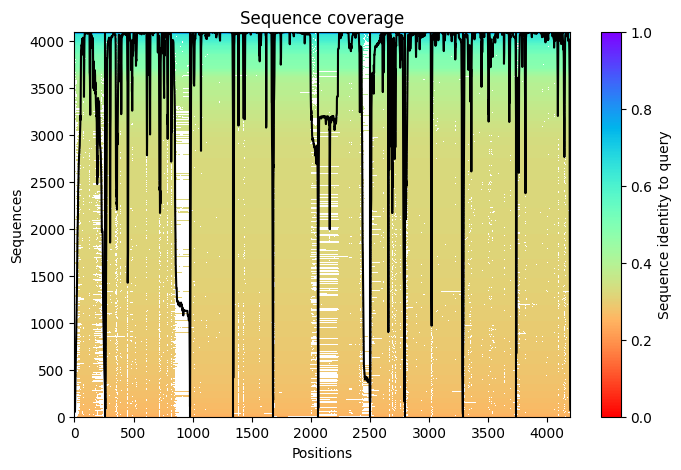

GC 6308


In [17]:
#@title prep_inputs
#@markdown Copy and Paste as many sequences as you need seperated by ":" , then in the Jobname write the name of each seperated by "-"
sequence = "MNPGQDREKI VNIEERIPKI KEQRKQKANR RLISFIMLFF IMVLIIVYLQ TPISKVSTIS VTGNENVSKK EIIDLSDINS GDTEFWSLDK QKTEKKIQQN KLVKKAEISK SLPNKINIAI EEYKAIAYLE KDDVYYEVLE  NGSVLPNEVT PDDAGPILVN WTNAKKRSQM AKQLDALSNS LKQSISEIYY TPVKMDENRI KLYMNDGYVV TASIKTFADR MKTYPSIISQ LSSNKKGIIH LEVATYFEEF GKNDKAAKKE DEN:MIQMPKKNKF MNRGAAILSI CFALFFFVIL GRMAYIQITG KANGEVLATK ATEQHEKKRT IEASRGSILD RKGKVIAEDT ATYKLIAILD KKMTTDVKHP QHVVNKEKTA EALSKVINLD KADILDILNK DAKQVEFGSA  GRDITYSQKQ KIEKMKLPGI SFLRDTKRYY PNGVFASNLI GYAEVDEETN EISGAMGLEK VLDKYLKERD GYVTYESDKS GWELPNSKNK ITAPKNGDNV YLTIDQKIQT FLEDSMTKVA QKYNPKKIMA AVVDPKTGKV  LAMGQRPSFD PNKRDVTNYY NDLISYAYEP GSTMKIFTLA AAMQENVFNA NEKYKSGTFE VGGAPVKDHN NGVGWGPTTY HDGVLRSSNV AFAKLAKEKL GYDRLNQYLH KFNFYQKTGI DLPGEVSSKI NFKYEFDKAS  TAYGQASAVT PIQQIQAATA IANDGKMMKP YVIDHIVDPD KDKTIYQNKP ESAGTPISAS TAKKVRDILG EVVTSKIGTG QAYKIEGFDV AGKTGTAQIA GKGGYLDGTD NYIFSFMGMA PKDDPELLIY VAVQQPQLKA  GQSSSDPVSE IFNPTMKNSL HYLNIEPTEK SDSDKEETKA QTMPDLTDQT VAAAQKKAKE ENLTPIVIGS DVAVKEQYPK ADEEVLTNQK VFLKTGGKIK MPDMTGWSRR EVLQYGELAG IHIEVSGQGY AVSQSVKKDK  EIKDKTVIKV KFKNPD:MTTKKTSPDL LLVIITLLLL TIGLIMVYSA SAVWADYKFD DSFFFAKRQL LFAGIGVIAM FFIMNVDYWT WRTWSKLLMV ICFFLLVLVL IPGVGMVRNG SRSWIGVGAF SIQPSEFMKL AMIAFLAKFL SEKQKNITSF  RRGFVPALGI VFSAFLIIMC QPDLGTGTVM VGTCIVMIFV AGARIAHFVF LGLIGLSGFV GLVLSAPYRI KRITSYLNPW EDPLGSGFQI IQSLYAVGPG GLFGMGLGQS RQKFFYLPEP QTDFIFAILS EELGFIGGTL  ILLLFSVLLW RGIRIALGAP DLYGSFVAVG IISMIAIQVM INIGVVTGLI PVTGITLPFL SYGGSSLTLM LMAVGVLLNV SRYSRY:MFGIGARDLG IDLGTANTLV FVKGKGIVVR EPSVVALQTD TKSIVAVGND AKNMIGRTPG NVVALRPMKD GVIADYETTA TMMKYYINQA IKNKGMFARK PYVMVCVPSG ITAVEERAVI DATRQAGARD  AYPIEEPFAA AIGANLPVWE PTGSMVVDIG GGTTEVAIIS LGGIVTSQSI RVAGDEMDDA IINYIRKTYN LMIGDRTAEA IKMEIGSAEA PEESDNMEIR GRDLLTGLPK TIEITGKEIS NALRDTVSTI  VEAVKSTLEK TPPELAADIM DRGIVLTGGG ALLRNLDKVI SEETKMPVLI AEDPLDCVAI GTGKALEHIH LFKGKTR:MLEFETNIDGLASIKVIGVGGGGNNAVNRMIENEVQGVEYIAVNTDAQALNLSKAEVKMQIGAKLTRGLGAGANPEVGKKAAEESKEQIEEALKGADMVFVTAGMGGGTGTGAAPVIAQIAKDLGALTVGVVTRPFTFEGRKRQLQAAGGISAMKEAVDTLIVIPNDRILEIVDKNTPMLEAFREADNVLRQGVQGISDLIATPGLINLDFADVKTIMSNKGSALMGIGIATGENRAAEAAKKAISSPLLEAAIDGAQGVLMNITGGTNLSLYEVQEAADIVASASDQDVNMIFGSVINENLKDEIVVTVIATGFIEQEKDVTKPQRPSLNQSIKTHNQSVPKREPKREEPQQQNTVSRHTSQPADDTLDIPTFLRNRNKRG:MNNNELYVSLDIGTSNTKVIVGEMTDDSLNIIGVGNVPSEGLKKGSIVDIDETVHSIRKAFDQAERMVGFPLRKAIVGVNGNYINIQDTNGVVAVSSENKEIQVEDVRRVMEAAQVVSVPHEQLIVDVIPKQFIVDGRDEITDPKKMLGVRLEVEGTLITGSKTILHNLLRCVERAGIEITDICLQPLAAGSAALSKDEKNLGVALIDIGGGSTTIAVFQNGHLTSTRVIPLGGENITKDISIGLRTSTEEAERVKKQLGHAYYDEASEDEIFEVTVIGTNQKQTFTQQEAANIIEARVEEILEIVSEELRSMGITDLPGGFVLTGGQAAMPGVMSLAQDVLQNNVRVASPNYIGVRDPQYMTGVGLIQFACRNARIQGRKIGFKMPEEAIQEIAVSSSEEQEQHHHQNEVQQRPKGKQKTQAEHNKQSKMKKLLSMFWE:MPNKRLMLLLLCIIILVAMIGFSLKGGRNTTWPEKVIGDTTGVFQNIFHTPAEFFAGIFENINDLKNTYKENERLREKLDGQTQYEAKLQELEEENKSLRDELGHVKSIKDYKPILATVIARSPDNWAKQVTINKGTQQNVAKDMAVTNEKGALIGKIKSSGLNNFTSAVQLLSDTDRNNRVATKISGKKGSKGYGLIEGYDKEKKRLKMTIIERKDKQDVKKGDLIETSGTGGVFPEGLTIGEVTDIESDSYGLTKVAYVKPAADLTDLNNVIVVNRDVPTVDTEEEGS:MKLTKLLTYLTTEPSVNDSQDPEITSIEMDSREVKKGSLFVCVKGYTVDGHDFAQKAVENGAAAIVAEREVDVNVPVIIVRQSLRALSVLSDAFYGQPTKKLQLIGITGTNGKTSTTHMVDEILKKAGKRTGLIGTMYMKIGDETLPVKNTTPESVTLQKTFKKMNDKHVDTAIMEVSSHALSLGRVHGCDYDIAVFTNLTQDHLDYHKTMDEYRHAKSLLFSQLGGAFNHEHPKRAVLNADDEASAYFEKVTAAHISTYGIKNDADVMAKNISITAQGTSFDLVTNKGTKHITMSLVGQFNVYNVLAAVATCIAAGIPFEIITEAVEELHGVRGRFELVNQQQEFPVIVDYAHTPDSLENVLETCRDMTEGKLFVVVGCGGDRDKTKRPKMAKIAVELADEPIFTSDNPRSEDPRAILRDMEAGVENAYYHSIANREQAIFFAIANAKKGDVVLIAGKGHETYQQIGNETFDFDDAEVAARAIVELNKNKTNS:MENDQFLQKQHFLILGLAKSGYAAASILHEKGIYVAVNDQKPFEENEPAQKLSEKGIEVVCGEHPVSLFDQHQITILIKNPGIPYENIMVQEAEKRGIPVWTEIELAYYLTSAKFIGITGSNGKTTTTTLIYEMLKADSQKALIAGNIGTVASEVAYHADGDEWIVTELSSFQLMGTHAFRPEISLILNVFDAHLDYHHTRENYEKAKQKVYLHQTASDKAIVNQDDETVVRLAEAGKAEIVPFSVSKTLEQGAYVKDSMIMFNGEAILPLEEVVLPGAHNLENILAAIAVVKTAGASNEAVKKVLTSFTGVKHRLQYVTTVNGRKFYNDSKATNILATSKALSAFDKPVILLAGGLDRGNGFDDLKPYMKHVKAVLTFGQTAPKLEKLGNELGIQHVKRVDNVEQAVSAAFALSNEGDVILLSPACASWDQFKTFEERGDMFIDAVHMLK:MIKRTVKNIAEMVKGTLANPQYEQTVIHGVATDTRKLEQHQLFIPLKGERFDGHSFVEQAFEAGVAAVLWDRSVPNPPENHAVILVDDTLTALQQLAKAYLQELGTRVIGVTGSNGKTTTKDMIHAVLGTQYRVHKTGGNFNNHIGLPLTVLAMPENTEIAVLEMGMSAKGEIDLLSRLANPDAAVITNIGESHMQDLGSREGIAEAKLEIINGLKEDGVLIYIGDEPLLQNAYSCQTKTYGTGTHNDYQLQDVSQSEEGTHFTIKGIENTFFIPILGKHNVMNAMAAIAAGAYFGIAPEDAAKGLSGLKVTGMRLELIKTDSGLSIINDAYNASPTSMKAAIQLTESLEGYGKKMLVLGDMLELGDLEETFHKECGAVISPDKIDRVFTYGKLGAFIAEGALKHFEKDRVSHYTEKKDLLQAVKENASKGDLILFKASRGMKLEEIVKDLIESPLS" #@param {type:"string"}
jobname = "DivIVB-PbpB-SpoVE-MreB-FtsZ-FtsA-MreC-MurE-MurD-MurF" #@param {type:"string"}
jobname_backup = jobname
query_sequence = sequence
copies = 1
#@markdown ----
#@markdown **MSA options**
msa_method = "mmseqs2" #@param ["mmseqs2","single_sequence", "custom_fas", "custom_a3m", "custom_sto"]
pair_mode = "paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown filtering options
cov = 0 #@param ["0", "25", "50", "75", "90", "99"] {type:"raw"}
id = 100 #@param ["90", "95" "100"] {type:"raw"}
qid = 0 #@param ["0", "10", "15", "20", "30"] {type:"raw"}
do_not_filter = False #@param {type:"boolean"}


template_mode = "none"
use_templates = template_mode in ["mmseqs2","custom"]
pdb = ""
chain = "A"
rm_template_seq = False
propagate_to_copies = True
do_not_align = False
rm_sidechain = rm_sequence = rm_template_seq

# filter options
sequence = sequence.upper()
sequence = re.sub("[^A-Z:/()]", "", sequence.upper())
sequence = re.sub("\(",":(", sequence)
sequence = re.sub("\)","):", sequence)
sequence = re.sub(":+",":",sequence)
sequence = re.sub("/+","/",sequence)
sequence = re.sub("^[:/]+","",sequence)
sequence = re.sub("[:/]+$","",sequence)
jobname = re.sub(r'\W+', '', jobname)

# process sequence
sequences = sequence.split(":")
u_sequences = predict.get_unique_sequences(sequences)
u_cyclic = [x.startswith("(") for x in u_sequences]
u_sub_lengths = [[len(y) for y in x.split("/")] for x in u_sequences]
u_sequences = [x.replace("(","").replace(")","").replace("/","") for x in u_sequences]
if len(sequences) > len(u_sequences):
  print("WARNING: use copies to define homooligomers")
u_lengths = [len(x) for x in u_sequences]
sub_seq = "".join(u_sequences)
seq = sub_seq * copies

jobname = f"{jobname}_{predict.get_hash(seq)[:5]}"
def check(folder): return os.path.exists(folder)
if check(jobname):
  n = 0
  while check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

print("jobname",jobname)
print(f"length={u_lengths} copies={copies}")

input_opts = {"sequence":u_sequences,
              "copies":copies,
              "msa_method":msa_method,
              "pair_mode":pair_mode,
              "do_not_filter":do_not_filter,
              "cov":cov,
              "id":id,
              "template_mode":template_mode,
              "propagate_to_copies":propagate_to_copies}

def run_mmseqs2_wrapper(*args, **kwargs):
  kwargs['user_agent'] = "colabdesign/gamma"
  return run_mmseqs2(*args, **kwargs)

##################
# GET MSA
##################
os.makedirs(jobname, exist_ok=True)

Ls = [len(x) for x in u_sequences]
if msa_method == "mmseqs2":
  msa, deletion_matrix = predict.get_msa(u_sequences, jobname,
    mode=pair_mode,
    cov=cov, id=id, qid=qid, max_msa=4096,
    do_not_filter=do_not_filter,
    mmseqs2_fn=run_mmseqs2_wrapper,
    hhfilter_fn=run_hhfilter)

elif msa_method == "single_sequence":
  with open(f"{jobname}/msa.a3m","w") as a3m:
    a3m.write(f">{jobname}\n{sub_seq}\n")
  msa, deletion_matrix = predict.parse_a3m(f"{jobname}/msa.a3m")

else:
  msa_format = msa_method.split("_")[1]
  print(f"upload {msa_method}")
  msa_dict = files.upload()
  lines = []
  for k,v in msa_dict.items():
    lines += v.decode().splitlines()
  input_lines = []
  for line in lines:
    line = line.replace("\x00","")
    if len(line) > 0 and not line.startswith('#'):
      input_lines.append(line)
  with open(f"{jobname}/msa.{msa_format}","w") as msa:
    msa.write("\n".join(input_lines))
  if msa_format != "a3m":
    os.system(f"perl hhsuite/scripts/reformat.pl {msa_format} a3m {jobname}/msa.{msa_format} {jobname}/msa.a3m")
  if do_not_filter:
    os.system(f"hhfilter -qid 0 -id 100 -cov 0 -i {jobname}/msa.a3m -o {jobname}/msa.filt.a3m")
  else:
    os.system(f"hhfilter -qid {qid} -id {id} -cov {cov} -i {jobname}/msa.a3m -o {jobname}/msa.filt.a3m")
  msa, deletion_matrix = predict.parse_a3m(f"{jobname}/msa.filt.a3m")

if len(msa) > 1:
  predict.plot_msa(msa, Ls)
  plt.savefig(f"{jobname}/msa_feats.png", dpi=200, bbox_inches='tight')
  plt.show()

##################
if use_templates:
  print("aligning template")
  template_msa = f"{jobname}/msa.a3m"
  if template_mode == "mmseqs2":
    predict.get_msa(u_sequences, jobname,
      mode="unpaired",
      mmseqs2_fn=run_mmseqs2_wrapper,
      do_not_filter=True,
      do_not_return=True,
      output_a3m=f"{jobname}/msa_tmp.a3m")
    template_msa = f"{jobname}/msa_tmp.a3m"
    if not propagate_to_copies and copies > 1:
      new_msa = []
      with open(template_msa, "r") as handle:
        for line in handle:
          if not line.startswith(">"):
            new_msa.append(line.rstrip())
      with open(template_msa, "w") as handle:
        for n,seq in enumerate(new_msa):
          handle.write(f">{n}\n{seq*copies}\n")

    templates = {}
    print("ID\tpdb\tcid\tevalue")
    for line in open(f"{jobname}/msa/_env/pdb70.m8","r"):
      p = line.rstrip().split()
      M,target_id,qid,e_value = p[0],p[1],p[2],p[10]
      M = int(M)
      if M not in templates:
        templates[M] = []
      if len(templates[M]) < 4:
        print(f"{int(M)}\t{target_id}\t{qid}\t{e_value}")
        templates[M].append(target_id)
    if len(templates) == 0:
      use_templates = False
      print("ERROR: no templates found...")
    else:
      Ms = sorted(list(templates.keys()))
      pdbs,chains = [],[]
      for M in Ms:
        for n,target_id in enumerate(templates[M]):
          pdb_id,chain_id = target_id.split("_")
          if len(pdbs) < n+1:
            pdbs.append([])
            chains.append([])
          pdbs[n].append(pdb_id)
          chains[n].append(chain_id)
      print(pdbs)
  else:
    pdbs,chains = [pdb],[chain]

if use_templates:
  input_opts.update({"pdbs":pdbs, "chains":chains})
  batches = []
  for pdb,chain in zip(pdbs,chains):
    query_seq = "".join(u_sequences)
    batch = predict.get_template_feats(pdb, chain,
      query_seq=query_seq,
      query_a3m=template_msa,
      copies=copies,
      propagate_to_copies=propagate_to_copies,
      use_seq=not rm_sequence,
      get_pdb_fn=get_pdb,
      align_fn=run_do_not_align if do_not_align else run_hhalign)
    batches.append(batch)

  # for display
  plt.figure(figsize=(3*len(batches),3))
  for n,batch in enumerate(batches):
    plt.subplot(1,len(batches),n+1)
    plt.title(f"template features {n+1}")
    dgram = batch["dgram"].argmax(-1).astype(float)
    dgram[batch["dgram"].sum(-1) == 0] = np.nan
    Ln = dgram.shape[0]
    plt.imshow(dgram, extent=(0, Ln, Ln, 0))
    predict.plot_ticks(Ls * copies)
  plt.savefig(f"{jobname}/template_feats.png", dpi=200, bbox_inches='tight')
  plt.show()
else:
  batches = [None]

################
print("GC",gc.collect())

In [18]:
#@title Sequence seperation and counting
# Step 1: Split the sequence by ":" to create individual segments
sequence_segments = sequence.split(":")

# Step 2: Split jobname by "-" to get individual job names
job_names = jobname_backup.split("-")

# Check if the number of sequence segments and job names match
if len(sequence_segments) != len(job_names):
    print("Warning: The number of job names and sequence segments do not match.")
    print(f"Number of job names: {len(job_names)}, Number of sequence segments: {len(sequence_segments)}")

# Step 3: Calculate lengths of each segment in the sequence
sequence_lengths = [len(segment.replace(" ", "")) for segment in sequence_segments]

# Step 4: Pair each job name with the corresponding sequence length
# Handle mismatched lengths by pairing up to the shorter of the two lists
length_name_pairs = list(zip(job_names, sequence_lengths))

# Output the results
for name, length in length_name_pairs:
    print(f"Job Name: {name}, Sequence Length: {length}")

# Optionally, report any extra segments or names if they don't match
if len(sequence_segments) > len(job_names):
    print("Additional sequence segments without job names:", sequence_segments[len(job_names):])
elif len(job_names) > len(sequence_segments):
    print("Additional job names without sequence segments:", job_names[len(sequence_segments):])


Job Name: DivIVB, Sequence Length: 263
Job Name: PbpB, Sequence Length: 716
Job Name: SpoVE, Sequence Length: 366
Job Name: MreB, Sequence Length: 337
Job Name: FtsZ, Sequence Length: 382
Job Name: FtsA, Sequence Length: 440
Job Name: MreC, Sequence Length: 290
Job Name: MurE, Sequence Length: 494
Job Name: MurD, Sequence Length: 451
Job Name: MurF, Sequence Length: 457


In [19]:
# Define sequence_segments as a list of individual segments (pre-trimming)
sequence_segments = sequence.split(":")

# Assuming job_names is already defined as the corresponding job names list
job_names = jobname_backup.split("-")

# Step 1: Calculate starting boundaries for each segment (pre-trimming)
segment_boundaries = []
current_start = 0

# Calculate the start and end position of each segment before trimming
for segment, name in zip(sequence_segments, job_names):
    current_end = current_start + len(segment.replace(" ", ""))  # Length of segment
    segment_boundaries.append((name, current_start, current_end))  # Store segment boundaries (start, end)
    current_start = current_end  # Update start for the next segment

# Output segment boundaries before trimming
for name, start, end in segment_boundaries:
    print(f"Job Name: {name}, Start: {start}, End: {end}")

Job Name: DivIVB, Start: 0, End: 263
Job Name: PbpB, Start: 263, End: 979
Job Name: SpoVE, Start: 979, End: 1345
Job Name: MreB, Start: 1345, End: 1682
Job Name: FtsZ, Start: 1682, End: 2064
Job Name: FtsA, Start: 2064, End: 2504
Job Name: MreC, Start: 2504, End: 2794
Job Name: MurE, Start: 2794, End: 3288
Job Name: MurD, Start: 3288, End: 3739
Job Name: MurF, Start: 3739, End: 4196


In [20]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
#@title MMSEQ2 cleaning
def clean_and_adjust_sequences(sequences):
    """
    Cleans each sequence by removing newlines, spaces, and lowercase letters.
    Then, trims all sequences to ensure they are the same length, matching the shortest sequence.

    Parameters:
    sequences (list of SeqRecord): List of sequences to be cleaned and adjusted.

    Returns:
    cleaned_sequences (list of SeqRecord): List of cleaned and uniformly trimmed sequences.
    """
    # Step 1: Clean each sequence by removing unwanted characters (newlines, spaces, and lowercase letters)
    cleaned_sequences = [
        SeqRecord(
            Seq("".join([char for char in str(record.seq) if char.isupper() or char == '-'])),
            id=record.id,
            description=""
        )
        for record in sequences
    ]

    # Step 2: Find the minimum length among the cleaned sequences
    min_length = min(len(record.seq) for record in cleaned_sequences)
    print(f"Minimum cleaned sequence length: {min_length}")

    # Step 3: Trim all sequences to the minimum length to ensure uniform alignment
    adjusted_sequences = [
        SeqRecord(Seq(str(record.seq)[:min_length]), id=record.id, description="")
        for record in cleaned_sequences
    ]

    return adjusted_sequences

# Load and process the sequences from an input .a3m file
input_file = f"/content/{jobname}/msa.a3m"  # Replace with your actual file path
sequences = list(SeqIO.parse(input_file, "fasta"))

# Clean and adjust sequences
uniform_cleaned_sequences = clean_and_adjust_sequences(sequences)

# Save the cleaned and adjusted sequences to a new .a3m file
output_file = f"/content/{jobname}/msa.a3m"  # Define your output file path
with open(output_file, "w") as output_handle:
    SeqIO.write(uniform_cleaned_sequences, output_handle, "fasta")  # Use FASTA format for A3M files

Minimum cleaned sequence length: 4196


In [21]:
import numpy as np
import random
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

# ==========================================================
# 1. Trim alignment to target length
# ==========================================================
def reduce_alignment_to_target_length(sequences, min_target_length=600, max_target_length=600):
    # Remove lowercase letters and build alignment matrix
    alignment_matrix = np.array([
        [char for char in str(record.seq) if char.isupper() or char == '-']
        for record in sequences
    ], dtype=str)

    alignment_length = alignment_matrix.shape[1]
    print(f"Original alignment length (after removing lowercase): {alignment_length}")

    min_length_after_removal = min(len(str(record.seq).replace(' ', '').upper()) for record in sequences)
    target_length = min(max(min_length_after_removal, min_target_length), max_target_length)

    if alignment_length > target_length:
        columns_to_remove = alignment_length - target_length
        removed_columns = sorted(random.sample(range(alignment_length), columns_to_remove))
        print(f"Removed columns: {removed_columns}")
    else:
        removed_columns = []

    trimmed_sequences = trim_sequences_to_remove_columns(sequences, removed_columns)
    return trimmed_sequences, removed_columns, target_length

def trim_sequences_to_remove_columns(sequences, removed_columns):
    trimmed_sequences = []
    removed_columns_set = set(removed_columns)
    for record in sequences:
        sequence = str(record.seq)
        trimmed_sequence = "".join([sequence[i] for i in range(len(sequence)) if i not in removed_columns_set])
        trimmed_sequences.append(SeqRecord(Seq(trimmed_sequence), id=record.id, description=""))
    return trimmed_sequences

def process_msa_file(input_file, segment_boundaries, min_target_length=600, max_target_length=600):
    sequences = list(SeqIO.parse(input_file, "fasta"))
    trimmed_sequences, removed_columns, target_length = reduce_alignment_to_target_length(
        sequences, min_target_length, max_target_length
    )

    new_segment_boundaries = []
    for name, original_start, original_end in segment_boundaries:
        new_start = original_start
        new_end = original_end
        num_removed_before_start = sum(1 for col in removed_columns if col < original_start)
        new_start -= num_removed_before_start
        num_removed_between_start_end = sum(1 for col in removed_columns if original_start <= col < original_end)
        new_end -= (num_removed_before_start + num_removed_between_start_end)
        new_segment_boundaries.append((name, new_start, new_end))
        print(f"Job Name: {name}, New Start: {new_start}, New End: {new_end}")

    return trimmed_sequences, removed_columns, new_segment_boundaries, target_length

# ==========================================================
# 2. GREMLIN helpers
# ==========================================================
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()
import matplotlib.pylab as plt
from scipy.spatial.distance import pdist, squareform
import pandas as pd

alphabet = "ARNDCQEGHILKMFPSTWYV-"
states = len(alphabet)
a2n = dict((a, n) for n, a in enumerate(alphabet))
aa2int = lambda x: a2n.get(x, a2n['-'])

def parse_a3m(filename):
    names, seqs, current_seq = [], [], ""
    with open(filename, "r") as file:
        for line in file:
            line = line.rstrip()
            if line.startswith(">"):
                if current_seq:
                    current_seq = ''.join([c if c.isupper() or c == '-' else '' for c in current_seq])
                    if current_seq.strip():
                        seqs.append(current_seq)
                current_seq = ""
                names.append(line[1:])
            else:
                current_seq += line
        if current_seq:
            current_seq = ''.join([c if c.isupper() or c == '-' else '' for c in current_seq])
            if current_seq.strip():
                seqs.append(current_seq)
    return names, seqs

def filt_gaps(msa, gap_cutoff=1.0):
    frac_gaps = np.mean((msa == states-1).astype(float), 0)
    non_gaps = np.where(frac_gaps < gap_cutoff)[0]
    return msa[:, non_gaps], non_gaps

def get_eff(msa, eff_cutoff=0.8):
    msa_sm = 1.0 - squareform(pdist(msa, "hamming"))
    msa_w = (msa_sm >= eff_cutoff).astype(float)
    msa_w = 1.0 / np.sum(msa_w, -1)
    return msa_w

def str2int(x):
    if x.dtype.type is np.str_:
        if x.ndim == 0:
            return np.array([aa2int(aa) for aa in x])
        else:
            return np.array([[aa2int(aa) for aa in seq] for seq in x])
    else:
        return x

def split_train_test(seqs, frac_test=0.1):
    x = np.copy(seqs)
    np.random.shuffle(x[1:])
    split = int(len(x) * (1.0-frac_test))
    return x[:split], x[split:]

def mk_msa(seqs, gap_cutoff=1.0, eff_cutoff=0.8):
    msa_ori = str2int(seqs)
    msa, v_idx = filt_gaps(msa_ori)
    msa_weights = get_eff(msa, eff_cutoff)
    return {"msa_ori": msa_ori, "msa": msa, "weights": msa_weights,
            "neff": np.sum(msa_weights), "v_idx": v_idx,
            "nrow": msa.shape[0], "ncol": msa.shape[1], "ncol_ori": msa_ori.shape[1]}

def opt_adam(loss, name, var_list=None, lr=1.0, b1=0.9, b2=0.999, b_fix=False):
    if var_list is None:
        var_list = tf.trainable_variables()
    gradients = tf.gradients(loss, var_list)
    opt = []
    for n, (x, g) in enumerate(zip(var_list, gradients)):
        if g is not None:
            mt = tf.get_variable(name+"_mt_"+str(n), shape=list(x.shape),
                                 initializer=tf.zeros_initializer, trainable=False)
            vt = tf.get_variable(name+"_vt_"+str(n), shape=[], initializer=tf.zeros_initializer, trainable=False)
            mt_tmp = b1*mt+(1-b1)*g
            vt_tmp = b2*vt+(1-b2)*tf.reduce_sum(tf.square(g))
            lr_tmp = lr/(tf.sqrt(vt_tmp)+1e-8)
            opt.append(x.assign_add(-lr_tmp * mt_tmp))
            opt.append(vt.assign(vt_tmp))
            opt.append(mt.assign(mt_tmp))
    return tf.group(opt)
from collections import defaultdict


def GREMLIN(msa, opt_iter=100, opt_rate=1.0, batch_size=100, lam_v=0.01, lam_w=0.01, scale_lam_w=True,
            v=None, w=None, ignore_gap=False):
    tf.reset_default_graph()
    ncol = msa["ncol"]

    MSA = tf.placeholder(tf.int32, shape=(None, ncol), name="msa")
    MSA_weights = tf.placeholder(tf.float32, shape=(None,), name="msa_weights")
    OH_MSA = tf.one_hot(MSA, states)
    if ignore_gap:
        ncat = states-1
        NO_GAP = 1.0 - OH_MSA[..., -1]
        OH_MSA = OH_MSA[..., :ncat]
    else:
        ncat = states

    V = tf.get_variable(name="V", shape=[ncol, ncat], initializer=tf.zeros_initializer)
    W_tmp = tf.get_variable(name="W", shape=[ncol, ncat, ncol, ncat], initializer=tf.zeros_initializer)
    W = W_tmp + tf.transpose(W_tmp, [2, 3, 0, 1])
    W = W * (1-np.eye(ncol))[:, None, :, None]

    VW = V + tf.tensordot(OH_MSA, W, 2)
    H = tf.reduce_sum(OH_MSA*VW, -1)
    Z = tf.reduce_logsumexp(VW, -1)
    PLL = H - Z
    if ignore_gap:
        PLL = PLL * NO_GAP
    PLL = tf.reduce_sum(PLL, -1)
    PLL = tf.reduce_sum(MSA_weights*PLL) / tf.reduce_sum(MSA_weights)

    L2_V = lam_v * tf.reduce_sum(tf.square(V))
    L2_W = lam_w * tf.reduce_sum(tf.square(W)) * 0.5
    if scale_lam_w:
        L2_W = L2_W * (ncol-1) * (states-1)

    loss = -PLL + (L2_V + L2_W) / msa["neff"]
    opt = opt_adam(loss, "adam", lr=opt_rate)

    all_idx = np.arange(msa["nrow"])
    def feed(feed_all=False):
        if batch_size is None or feed_all:
            return {MSA: msa["msa"], MSA_weights: msa["weights"]}
        else:
            batch_idx = np.random.choice(all_idx, size=batch_size)
            return {MSA: msa["msa"][batch_idx], MSA_weights: msa["weights"][batch_idx]}

    with tf.Session() as sess:
        sess.run(tf.global_variables_initializer())
        if v is None:
            oh_msa = np.eye(states)[msa["msa"]]
            if ignore_gap: oh_msa = oh_msa[..., :-1]
            pseudo_count = 0.01 * np.log(msa["neff"])
            f_v = np.einsum("nla,n->la", oh_msa, msa["weights"])
            V_ini = np.log(f_v + pseudo_count)
            if lam_v > 0: V_ini = V_ini - np.mean(V_ini, axis=-1, keepdims=True)
            sess.run(V.assign(V_ini))
        else:
            sess.run(V.assign(v))
        if w is not None:
            sess.run(W_tmp.assign(w*0.5))

        get_loss = lambda: np.round(sess.run(loss, feed(True)) * msa["neff"], 2)
        print("starting", get_loss())
        for i in range(opt_iter):
            sess.run(opt, feed())
            if (i+1) % int(opt_iter/10) == 0:
                print("iter", (i+1), get_loss())

        V_ = sess.run(V)
        W_ = sess.run(W)

    no_gap_states = states - 1
    return {"v": V_[:, :no_gap_states], "w": W_[:, :no_gap_states, :, :no_gap_states],
            "v_idx": msa["v_idx"], "len": msa["ncol_ori"]}

# ==========================================================
# 3. BOOTSTRAP LOOP
# ==========================================================
n_bootstrap = 50 #@param
all_mrfs = []
all_boundaries = []
all_removed_columns = []
for i in range(n_bootstrap):
    print(f"\n=== Bootstrap iteration {i+1}/{n_bootstrap} ===")
    trimmed_sequences, removed_columns, new_segment_boundaries, target_length = process_msa_file(
        f"/content/{jobname}/msa.a3m", segment_boundaries
    )
    output_file = f"/content/{jobname}/trimmed_alignment_{i}.a3m"
    with open(output_file, "w") as output_handle:
        SeqIO.write(trimmed_sequences, output_handle, "fasta")

    headers, seqs = parse_a3m(output_file)
    all_removed_columns.append(removed_columns)
    train_seqs, test_seqs = split_train_test(np.array(seqs, dtype=object), frac_test=0.1)
    np.random.shuffle(train_seqs)
    msa = mk_msa(np.array([list(seq) for seq in train_seqs]), gap_cutoff=1.0, eff_cutoff=0.8)

    mrf = GREMLIN(msa, lam_w=0.01)
    all_mrfs.append(mrf)
    all_boundaries.append(new_segment_boundaries)
    # --- make sure this is defined before the bootstrap loop ---
# all_mrfs already collected as all_mrfs

# ... your bootstrap loop that appends new_segment_boundaries ...
# inside loop you must append:
#    all_boundaries.append(new_segment_boundaries)
#
# After the loop finishes, compute consensus boundaries:

import numpy as np

from collections import defaultdict

import numpy as np
import numpy as np

def average_mrfs_using_original_positions(
    all_mrfs,
    all_boundaries,
    all_removed_columns,
    original_segment_boundaries,
    total_target=600
):
    """
    Average multiple MRFs using original MSA positions to correctly assign residues to proteins.
    Uses original removed-column mappings to backmap each amino acid to its true column.
    """
    ncols = total_target
    nstates = all_mrfs[0]["v"].shape[1]

    # Use the true original total sequence length for scaling (global)
    original_total = original_segment_boundaries[-1][2]
    compressed_total = total_target
    scale_factor = compressed_total / original_total

    final_boundaries = []
    for name, s, e in original_segment_boundaries:
        new_s = int(round(s * scale_factor))
        new_e = int(round(e * scale_factor))
        final_boundaries.append((name, new_s, new_e))
    # Adjust last boundary to exactly match total_target
    if final_boundaries[-1][2] != total_target:
        name, s, _ = final_boundaries[-1]
        final_boundaries[-1] = (name, s, total_target)
    print(f"Scaled final boundaries by {scale_factor:.3f}")

    # --- initialize accumulators ---
    v_accum = np.zeros((ncols, nstates))
    v_counts = np.zeros(ncols)
    w_accum = np.zeros((ncols, nstates, ncols, nstates))
    w_counts = np.zeros((ncols, ncols))

    # ==========================================================
    # iterate over each bootstrap
    # ==========================================================
    for mrf, bounds, removed_columns in zip(all_mrfs, all_boundaries, all_removed_columns):
        trimmed_len = mrf["len"]
        v_idx_trimmed = mrf["v_idx"]
        v = mrf["v"]
        w = mrf["w"]

        total_original_len = trimmed_len + len(removed_columns)
        original_positions = np.array([i for i in range(total_original_len) if i not in removed_columns])
        if np.max(v_idx_trimmed) >= len(original_positions):
            print(f"Skipping out-of-range indices in MRF (max v_idx={np.max(v_idx_trimmed)}, len(original_positions)={len(original_positions)})")
            v_idx_trimmed = v_idx_trimmed[v_idx_trimmed < len(original_positions)]

        v_idx_original = original_positions[v_idx_trimmed]

        # ==========================================================
        # improved residue-to-bin mapping (no empty columns)
        # ==========================================================

    # --- Accumulate all residues globally (includes inter- and intra-protein pairs) ---
    # --- Fractional (linear) binning to avoid empty columns ---
    for li, orig_pos in enumerate(v_idx_original):
        pos = orig_pos * scale_factor  # fractional bin position
        low = int(np.floor(pos))
        high = int(np.ceil(pos))
        weight_high = pos - low
        weight_low = 1 - weight_high

        low = np.clip(low, 0, ncols - 1)
        high = np.clip(high, 0, ncols - 1)

        # Accumulate v contributions
        v_accum[low] += v[li] * weight_low
        v_counts[low] += weight_low
        v_accum[high] += v[li] * weight_high
        v_counts[high] += weight_high

        # Accumulate w contributions
        for lj, orig_pos2 in enumerate(v_idx_original):
            pos2 = orig_pos2 * scale_factor
            low2 = int(np.floor(pos2))
            high2 = int(np.ceil(pos2))
            weight2_high = pos2 - low2
            weight2_low = 1 - weight2_high
            low2 = np.clip(low2, 0, ncols - 1)
            high2 = np.clip(high2, 0, ncols - 1)

            # Add contributions to all four combinations of low/high bins
            w_accum[low, :, low2, :] += w[li, :, lj, :] * weight_low * weight2_low
            w_accum[low, :, high2, :] += w[li, :, lj, :] * weight_low * weight2_high
            w_accum[high, :, low2, :] += w[li, :, lj, :] * weight_high * weight2_low
            w_accum[high, :, high2, :] += w[li, :, lj, :] * weight_high * weight2_high

            w_counts[low, low2] += weight_low * weight2_low
            w_counts[low, high2] += weight_low * weight2_high
            w_counts[high, low2] += weight_high * weight2_low
            w_counts[high, high2] += weight_high * weight2_high
    # ==========================================================

    zero_cols = np.where(v_counts == 0)[0]
    print(f"Empty columns: {len(zero_cols)} / {ncols}")

    # --- average safely ---
    avg_v = np.zeros_like(v_accum)
    np.divide(v_accum, v_counts[:, None], out=avg_v, where=v_counts[:, None] > 0)

    avg_w = np.zeros_like(w_accum)
    for i in range(ncols):
        for j in range(ncols):
            if w_counts[i, j] > 0:
                avg_w[i, :, j, :] = w_accum[i, :, j, :] / w_counts[i, j]

    mrf_avg = {"v": avg_v, "w": avg_w, "v_idx": np.arange(ncols), "len": ncols}

    print("\nAveraging complete.")
    print("Final MRF length:", ncols)
    print("Final boundaries:")
    for name, s, e in final_boundaries:
        print(f"  {name}: start={s}, end={e}")
    print("Sum of all boundary lengths:", sum(e - s for _, s, e in final_boundaries))

    return mrf_avg, final_boundaries
mrf_avg, final_boundaries = average_mrfs_using_original_positions(
    all_mrfs,                 # list of MRFs from bootstraps
    all_boundaries,           # list of boundaries for each MRF
    all_removed_columns,      # list of removed columns for each MRF
    segment_boundaries,       # original segment boundaries before trimming
    total_target=600          # final compressed MRF length
)
mrf = mrf_avg



=== Bootstrap iteration 1/50 ===
Original alignment length (after removing lowercase): 4196
Removed columns: [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 56, 57, 58, 59, 61, 62, 63, 64, 66, 68, 69, 70, 71, 72, 74, 75, 76, 78, 79, 82, 83, 84, 88, 89, 90, 91, 93, 94, 95, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 122, 123, 125, 126, 127, 129, 130, 131, 132, 133, 135, 137, 138, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 210, 211, 212, 213, 214, 216, 217, 218, 219, 220, 221, 222, 22

In [22]:
def score(mrf, x, recompute_z=False):
  x = str2int(x)

  # if length of sequence != length of model
  if x.shape[-1] != len(mrf["v_idx"]):
    x = x[...,mrf["v_idx"]]

  # one hot encode
  x = np.eye(states)[x]

  # get non-gap positions
  no_gap = 1.0 - x[...,-1]

  # remove gap from one-hot-encoding
  x = x[...,:-1]

  # compute score
  vw = mrf["v"] + np.tensordot(x,mrf["w"],2)

  # ============================================================================================
  # Note, Z (the partition function) is a constant. In GREMLIN, V, W & Z are estimated using all
  # the original weighted input sequence(s). It is NOT recommended to recalculate Z with a
  # different set of sequences. Given the common ERROR of recomputing Z, we include the option
  # to do so, for comparison.
  # ============================================================================================
  h = np.sum(np.multiply(x,vw),axis=-1)
  if recompute_z:
    z = logsumexp(vw, axis=-1)
    return np.sum((h-z), axis=-1)
  else:
    return np.sum(h, axis=-1)

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy import stats

def normalize(x):
    '''Normalize the input matrix using the Box-Cox transformation'''
    x = stats.boxcox(x - np.amin(x) + 1.0)[0]
    x_mean = np.mean(x)
    x_std = np.std(x)
    return (x - x_mean) / x_std

def get_mtx(mrf, apc_factor=0.95):
    """
    Convert MRF (Markov Random Field) to MTX (matrix/contact map) with softer APC.

    Parameters:
    - mrf: dict containing MRF ('w' and 'v_idx')
    - apc_factor: fraction of APC to subtract (0 = no APC, 1 = full APC)
    """
    # Raw L2-norm of each 20x20 interaction matrix
    raw_sq = np.sqrt(np.sum(np.square(mrf["w"]), axis=(1, 3)))

    # APC (average product correction)
    row_sum = np.sum(raw_sq, axis=1, keepdims=True)
    col_sum = np.sum(raw_sq, axis=0, keepdims=True)
    total_sum = np.sum(raw_sq)
    ap_sq = row_sum * col_sum / total_sum

    # Softer APC subtraction
    apc = squareform(raw_sq - apc_factor * ap_sq, checks=False)

    # Scale to [-1,1] to preserve high signals
    max_val = np.max(np.abs(apc))
    scaled_apc = apc / max_val if max_val > 0 else apc

    # Extract upper-triangle indices for matrix representation
    i, j = np.triu_indices_from(raw_sq, k=1)

    mtx = {
        "i": mrf["v_idx"][i],
        "j": mrf["v_idx"][j],
        "raw": squareform(raw_sq, checks=False),
        "apc": scaled_apc,
        "len": mrf["len"]
    }

    return mtx

import matplotlib.pyplot as plt
import numpy as np

def plot_mtx(mtx, final_boundaries, jobname="coev_output"):
    """
    Plot averaged GREMLIN coevolution contact map (Z-score, APC, or raw norm)
    with final protein segment boundaries shown.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 10))

    L = mtx["len"]

    # --- Build symmetric coevolution matrix ---
    if "zscore" in mtx:
        m = np.zeros((L, L))
        m[mtx["i"], mtx["j"]] = mtx["zscore"]
        m[mtx["j"], mtx["i"]] = mtx["zscore"]
    elif "apc" in mtx:
        m = np.zeros((L, L))
        m[mtx["i"], mtx["j"]] = mtx["apc"]
        m[mtx["j"], mtx["i"]] = mtx["apc"]
    elif "raw" in mtx:
        m = np.zeros((L, L))
        m[mtx["i"], mtx["j"]] = mtx["raw"]
        m[mtx["j"], mtx["i"]] = mtx["raw"]
    else:
        raise ValueError("mtx must contain 'zscore', 'apc', or 'raw'.")

    # --- Plot the matrix ---
    plt.imshow(m, cmap="Blues", vmin=0, vmax=0.5*np.nanmax(m))

    # Title with extra padding
    plt.title(f"GREMLIN Coevolution Map\n({jobname})", fontsize=13, pad=30)

    # Label axes with residues
    plt.xlabel("Residue Position", fontsize=10)
    plt.ylabel("Residue Position", fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

    # --- Draw start and end lines for each final protein boundary ---
    for seg_name, s, e in final_boundaries:
        s = max(0, min(int(s), L - 1))
        e = max(0, min(int(e), L - 1))

        # Start/end lines
        plt.axvline(x=s, color="blue", linestyle="--", linewidth=0.8)
        plt.axhline(y=s, color="blue", linestyle="--", linewidth=0.8)
        plt.axvline(x=e, color="red", linestyle="-", linewidth=0.8)
        plt.axhline(y=e, color="red", linestyle="-", linewidth=0.8)

        # Protein label in middle
        mid = (s + e) / 2
        plt.text(mid, -L*0.02, seg_name, ha="center", va="bottom",
                 fontsize=7, rotation=90)  # adjust position slightly above axis

    plt.tight_layout(pad=3.0)
    plt.savefig(f"co_ev_{jobname}.png", dpi=300)
    plt.show()





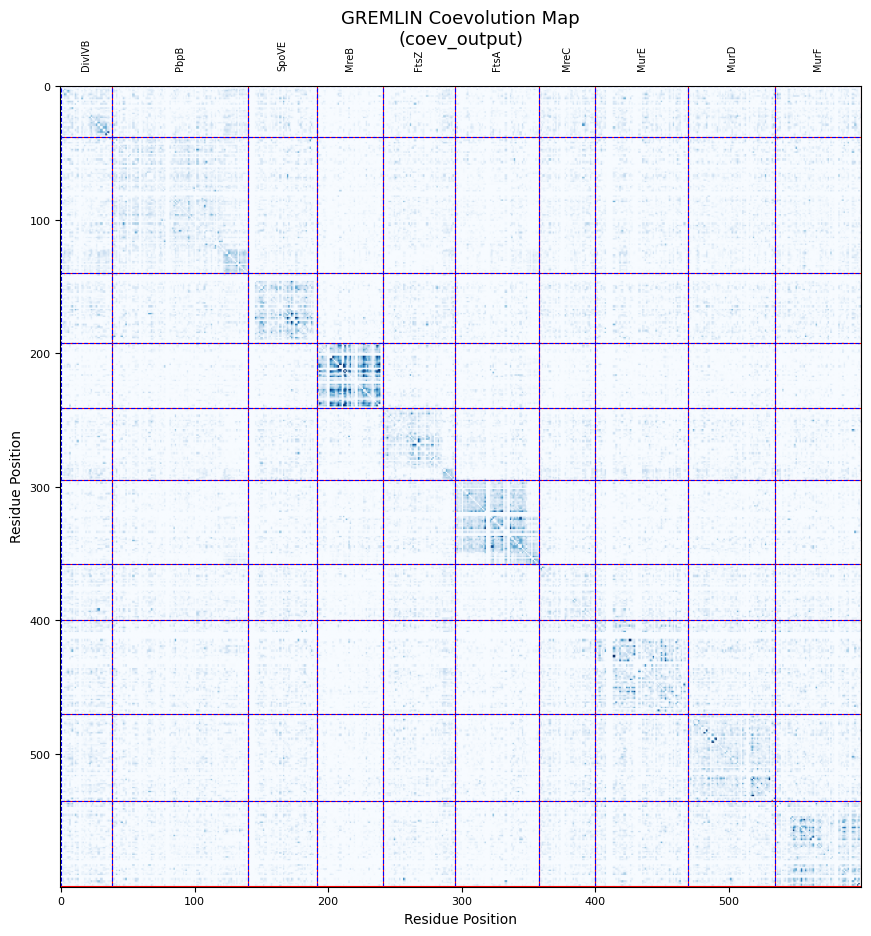

In [170]:
mtx = get_mtx(mrf)
plot_mtx(mtx,final_boundaries)

In [156]:
print("Final MRF length:", mrf_avg["len"])
print("Sum of boundaries:", sum(e - s for _, s, e in final_boundaries))

Final MRF length: 600
Sum of boundaries: 600


In [158]:
print("Keys in mtx:", mtx.keys())
print("zscore shape:", np.shape(mtx.get('apc', None)))
print("zscore stats:")
z = np.array(mtx.get('apc', []))
print("  min:", np.nanmin(z) if len(z) else None)
print("  max:", np.nanmax(z) if len(z) else None)
print("  mean:", np.nanmean(z) if len(z) else None)
gremcheck = (np.nanmean(z) if len(z) else None)

Keys in mtx: dict_keys(['i', 'j', 'raw', 'apc', 'len'])
zscore shape: (179700,)
zscore stats:
  min: -0.7385284767484602
  max: 1.0
  mean: 0.010397039790363364


In [159]:
#@title Data extraction

######################################################################################
# WARNING - WARNING - WARNING
######################################################################################
# - the index starts at 0
# - the "first" position is 0
# - in bioinformatics, the first position of a sequence is often "1"
#   for this index use i_aa and j_aa!

# adding amino acid to index+1 this is done again in the next step #message from Chris LB Graham
seq = seqs[0]
mtx["i_aa"] = [f"{seq[i]}_{i+1}" for i in mtx["i"]]
mtx["j_aa"] = [f"{seq[j]}_{j+1}" for j in mtx["j"]]

# load mtx into pandas dataframe
pd_mtx = pd.DataFrame(mtx,columns=["i","j","raw","apc","i_aa","j_aa"])
coev_mtx = pd.DataFrame(mtx,columns=["i","j","apc"])
# @markdown Please set the threshold to visualise in 3D and display in table form here. Please note that the residues above this threshold will be kept in the 'sorted_values.csv' A threshold of 2.5-3 or more is recommended, based on a limited dataset of available models currently.
import numpy as np
from numpy import load
import pandas as pd
GREM_threshold = gremcheck
# Assuming pd_mtx is your DataFrame
# Extracting columns i, j, and apc into a new DataFrame
new_df = pd_mtx[['i', 'j', 'apc']].copy()
df = new_df
df.columns = ["A", "B", "Score"]
df.to_csv('grem_file.csv', sep=' ', index=False)
df = df[(df['Score'] > GREM_threshold)]
df = df.add([1,1,0])
df = df.sort_values('Score',ascending=False)
df = df.reset_index()
del df['index']
df.to_csv('sorted_file.csv', sep=' ', index=False)


In [160]:
import pandas as pd
#@title Protein to Protein interaction labelling
# Step 1: Load the grem_file.csv (tab-delimited) and strip any leading/trailing spaces in column names
grem_df = pd.read_csv("grem_file.csv", sep=" ")
grem_df.columns = grem_df.columns.str.strip()  # Strip spaces from column names

# Display the columns and the first few rows to inspect the data
print("Columns in DataFrame:", grem_df.columns)
print("Initial DataFrame:")
print(grem_df.head())

# Step 3: Function to get segment name based on index
def get_segment_name(index, segment_boundaries):
    for name, start, end in segment_boundaries:
        if start <= index <= end:
            return name
    return None  # Return None if index doesn't match any segment

# Step 4: Add 1 to columns A and B to convert to 1-indexing
grem_df['A'] = grem_df['A'] + 1
grem_df['B'] = grem_df['B'] + 1

# Step 5: Assign segment names based on the new values of A and B
grem_df['name_i'] = grem_df['A'].apply(lambda x: get_segment_name(x, final_boundaries))
grem_df['name_j'] = grem_df['B'].apply(lambda x: get_segment_name(x, final_boundaries))

# The aa_i and aa_j columns will just be the same as columns A and B (after adding 1)
grem_df['aa_i'] = grem_df['A']  # Directly use the index from column A
grem_df['aa_j'] = grem_df['B']  # Directly use the index from column B

# Display the updated DataFrame with the new columns
print("Updated DataFrame:")
print(grem_df.head())

# Step 6: Save the updated DataFrame to a new CSV
# Write the result to a new tab-delimited CSV
grem_df[['name_i', 'name_j', 'aa_i', 'aa_j', 'Score']].to_csv('updated_grem_file_with_names.csv', sep="\t", index=False)

print("Updated CSV file has been saved as 'updated_grem_file_with_names.csv'.")


Columns in DataFrame: Index(['A', 'B', 'Score'], dtype='object')
Initial DataFrame:
   A  B  Score
0  0  1    0.0
1  0  2    0.0
2  0  3    0.0
3  0  4    0.0
4  0  5    0.0
Updated DataFrame:
   A  B  Score  name_i  name_j  aa_i  aa_j
0  1  2    0.0  DivIVB  DivIVB     1     2
1  1  3    0.0  DivIVB  DivIVB     1     3
2  1  4    0.0  DivIVB  DivIVB     1     4
3  1  5    0.0  DivIVB  DivIVB     1     5
4  1  6    0.0  DivIVB  DivIVB     1     6
Updated CSV file has been saved as 'updated_grem_file_with_names.csv'.


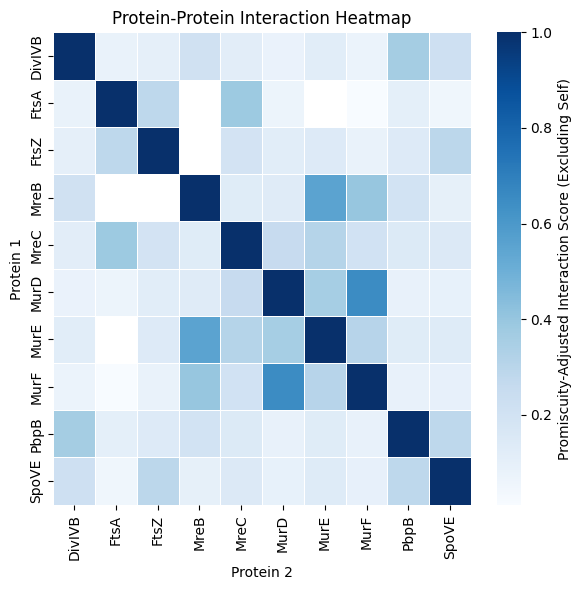

In [171]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load the updated GREM file
# -----------------------------
updated_grem_df = pd.read_csv("updated_grem_file_with_names.csv", sep="\t")

# -----------------------------
# Step 2: Average score per protein pair
# -----------------------------
average_scores = (
    updated_grem_df
    .groupby(['name_i', 'name_j'])['Score']
    .mean()
    .reset_index()
)

# -----------------------------
# Step 3: Create pivot matrix
# -----------------------------
score_matrix = average_scores.pivot(index='name_i', columns='name_j', values='Score')

# -----------------------------
# Step 4: Self-normalization (so self=1)
# -----------------------------
normalized_matrix = score_matrix.copy()

for name_j in score_matrix.columns:
    if name_j in score_matrix.index:
        self_score = score_matrix.loc[name_j, name_j]
        if pd.notna(self_score) and self_score != 0:
            normalized_matrix[name_j] = score_matrix[name_j] / self_score
        else:
            normalized_matrix[name_j] = 0
    else:
        normalized_matrix[name_j] = 0

normalized_matrix = normalized_matrix.fillna(0)

# Ensure diagonal = 1 after normalization
for name in normalized_matrix.index.intersection(normalized_matrix.columns):
    normalized_matrix.loc[name, name] = 1.0

# -----------------------------
# Step 5: Compute promiscuity weights (EXCLUDING self)
# -----------------------------
normalized_no_self = normalized_matrix.copy()
for name in normalized_no_self.index.intersection(normalized_no_self.columns):
    normalized_no_self.loc[name, name] = 0  # exclude self from totals

row_weights = normalized_no_self.sum(axis=1)
col_weights = normalized_no_self.sum(axis=0)

epsilon = 1e-8
row_weights_safe = row_weights + epsilon
col_weights_safe = col_weights + epsilon

# -----------------------------
# Step 6: Apply promiscuity adjustment
# -----------------------------
cross_normalized_matrix = normalized_matrix.div(row_weights_safe, axis=0).div(col_weights_safe, axis=1)

# -----------------------------
# Step 7: Reimpose self=1 constraint
# -----------------------------
for name in cross_normalized_matrix.index.intersection(cross_normalized_matrix.columns):
    cross_normalized_matrix.loc[name, name] = 1.0

# -----------------------------
# Step 8: Rescale (optional for interpretability)
# -----------------------------
cross_normalized_matrix = cross_normalized_matrix / cross_normalized_matrix.max().max()

# -----------------------------
# Step 9: Save normalized matrix
# -----------------------------
cross_normalized_matrix.to_csv('normalized_score_matrix.csv', sep="\t")

# -----------------------------
# Step 10: Long-format conversion
# -----------------------------
long_format = cross_normalized_matrix.reset_index().melt(
    id_vars=['name_i'], var_name='protein2', value_name='score'
)
long_format.rename(columns={'name_i': 'protein1'}, inplace=True)
long_format_filtered = long_format[long_format['score'] > 0]
long_format_filtered.to_csv('protein_interactions.csv', index=False)

# -----------------------------
# Step 11: Build symmetric matrix for visualization
# -----------------------------
df = long_format_filtered.copy()
df_reversed = df.rename(columns={'protein1': 'protein2', 'protein2': 'protein1'})
df_combined = pd.concat([df, df_reversed], ignore_index=True)
df_combined = df_combined.groupby(['protein1', 'protein2'], as_index=False)['score'].mean()

interaction_matrix = df_combined.pivot(index='protein1', columns='protein2', values='score')
interaction_matrix = interaction_matrix.combine_first(interaction_matrix.T)

# -----------------------------
# Step 12: Plot heatmap
# -----------------------------
plt.figure(figsize=(6, 6))
sns.heatmap(
    interaction_matrix,
    annot=False,
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Promiscuity-Adjusted Interaction Score (Excluding Self)'}
)
plt.title('Protein-Protein Interaction Heatmap')
plt.xlabel('Protein 2')
plt.ylabel('Protein 1')
plt.tight_layout()
plt.show()

In [168]:
import pandas as pd
import plotly.graph_objects as go
import networkx as nx
import random

# Load the protein-protein interaction data
df = pd.read_csv('protein_interactions.csv')

# Normalize the scores to range [0, 1] where the lowest score becomes 0 and highest becomes 1
score_min = df['score'].min()
score_max = df['score'].max()

# Normalize the scores
df['Normalized_Score'] = (df['score'] - score_min) / (score_max - score_min)

# Define the threshold for displaying interactions
threshold = 0.1  # Adjust this value as per your requirement (e.g., 0.1)

# Filter out rows where the normalized score is below the threshold
df_filtered = df[df['Normalized_Score'] >= threshold]

# Create a graph using NetworkX
G = nx.Graph()

# Add nodes and edges based on the protein-protein interactions and the normalized scores
for _, row in df_filtered.iterrows():
    protein1 = row['protein1']
    protein2 = row['protein2']
    score = row['Normalized_Score']

    # Add the edge with the normalized score as an attribute
    G.add_edge(protein1, protein2, weight=score)

for u, v, d in G.edges(data=True):
    d['weight_scaled'] = d['weight']**2  # square to emphasize strong interactions

pos = nx.spring_layout(G, k=0.3, weight='weight_scaled', iterations=150)

# Extract edge and node information for plotting
edge_x = []
edge_y = []
edge_widths = []  # Store edge widths based on score
for edge in G.edges(data=True):
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

    # Get the score (weight) of the current edge
    score = edge[2]['weight']

    # Assign edge width based on score thresholds
    if score >= 0.9:
        edge_widths.append(20)
    elif score >= 0.8:
        edge_widths.append(15)
    elif score >= 0.7:
        edge_widths.append(10)
    elif score >= 0.6:
        edge_widths.append(10)
    elif score >= 0.5:
        edge_widths.append(5)
    elif score >= 0.4:
        edge_widths.append(4)
    elif score >= 0.3:
        edge_widths.append(3)
    elif score >= 0.2:
        edge_widths.append(2)
    elif score >= 0.1:
        edge_widths.append(1)
    else:
        edge_widths.append(0)  # For scores below 0.1, set a minimum width of 1

# Create separate scatter traces for each edge to assign individual widths
edge_traces = []
for i, (edge, width) in enumerate(zip(G.edges(data=True), edge_widths)):
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]

    edge_trace = go.Scatter(
        x=[x0, x1],
        y=[y0, y1],
        line=dict(width=width, color='#888'),  # Set width dynamically for each edge
        hoverinfo='none',
        mode='lines'
    )
    edge_traces.append(edge_trace)

# Create node coordinates for the network (positions are obtained from spring_layout)
node_x = []
node_y = []
node_labels = []  # Store protein names for labeling
node_colors = []  # Store colors for each node
node_sizes = []   # Store node sizes based on degree

# Generate a random color for each node (you can also use specific logic to determine colors)
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_labels.append(node)  # Protein name as label
    # Assign a random color to each node
    node_colors.append(f'rgba({random.randint(0, 255)}, {random.randint(0, 255)}, {random.randint(0, 255)}, 0.8)')

    # Calculate node size based on its degree (number of connections)
    node_size = 10 + 10 * G.degree[node]  # Base size of 10, plus 10 for each connection
    node_sizes.append(node_size)

# Create the Plotly trace for nodes, now with annotations as text
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',  # Add text annotation
    marker=dict(
        color=node_colors,  # Each node gets its own color
        size=node_sizes,    # Size based on number of connections
        line=dict(width=1, color='black')
    ),
    text=node_labels,  # Protein names as annotations
    textposition='top center',  # Position the text on top of the node
    hoverinfo='none'   # Disable hover text, as it's redundant with annotations
)

# Combine all edge traces and node trace in a Plotly figure
fig = go.Figure(data=edge_traces + [node_trace],
                layout=go.Layout(
                    title="Protein-Protein Coevolution Interaction Network",
                    titlefont_size=28,
                    font_size=18,
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20, l=5, r=5, t=40),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )

# Display the network
fig.show()
